# мсп

## импортируем библиотеки

In [1]:
from esda.moran import Moran_Local
import matplotlib.pyplot as plt
from libpysal import weights
import dask.dataframe as dd
import dask_geopandas as gdd
import geopandas as gpd
import pandas as pd
import splot.esda
import re


## импортируем и предобрабатываем данные

### сбериндекс

In [2]:
# читаем два сырых файла сбериндекса

mun_xlsx = pd.read_excel('../data/sberindex/t_dict_municipal_districts.xlsx')

mun_geom = gpd.read_file(
    '../data/sberindex/t_dict_municipal_districts_poly.gpkg',
    driver='GPKG',
    engine='fiona',
)


In [3]:
# фильтруем сырые датафреймы, чтобы остались только актуальные границы и октмо

mun_xlsx = mun_xlsx.loc[mun_xlsx['year_to'] == 9999]
mun_geom = mun_geom.loc[mun_geom['year_to'] == 9999]

# меняем тип данных поля territory_id

mun_geom['territory_id'] = mun_geom['territory_id'].astype('int64')


In [4]:
# объёдиняем отфильтрованные датафреймы

mun = mun_geom.merge(mun_xlsx, how='outer', on='territory_id')


In [5]:
# удаляем ненужные поля
# переименовываем нужные, чтобы они соответствовали схеме бд пмо

mun = mun.filter(
    [
        'territory_id',
        'oktmo',
        'municipal_distric_name_short',
        'municipal_district_name',
        'region_code',
        'region_name',
        'geometry',
    ],
    axis='columns',
).rename(
    mapper={
        'municipal_district_name': 'municipality',
        'municipal_district_name_short': 'municipality_short',
        'region_code': 'region_id',
    },
    axis='columns',
)

# меняет формат записи и тип данных октмо

mun['oktmo'] = mun['oktmo'].str.replace('-', '').str.slice(0, 8).astype('int64')


### бд пмо

In [6]:
# читаем сырой файл бд пмо

sme = pd.read_csv(
    '../data/sme/data_Y48215003_112_v20250918.csv',
    sep=';',
    na_values=['ND', 'CD', 'UD', '', 'NA', 'NULL'],
)


In [7]:
# фильтруем сырой датафрейм по уровню муниципального образования

sme = sme.loc[sme['mun_level'] == 'Муниципальное образование верхнего уровня']

# меняем тип данных поля oktmo_stable и заполняем пропуски нулями

sme['oktmo_stable'] = sme['oktmo_stable'].fillna(0).astype('int64')

# удаляем ненужные поля

sme = sme.filter(
    [
        'oktmo',
        'oktmo_stable',
        'municipality',
        'region_id',
        'region_name',
        'year',
        'indicator_value',
        'comment',
    ],
    axis='columns',
)

# фильтруем датафрейм по году

sme_2020 = sme.loc[sme['year'] == 2020]


## объединяем датафреймы сбериндекса и бдпмо

### создаём и используем функцию объединения

In [8]:
# записываем функцию объединения


def sberindex_bdpmo(sberindex, bdpmo):

    gdf = sberindex
    df = bdpmo

    # объединяем два датафрейма по октмо

    first_merge = gdf.merge(df, on='oktmo', how='inner')

    # отделяем строки, которые не объединились по октмо

    df_only = df.loc[~df['oktmo'].isin(first_merge['oktmo'])]
    gdf_only = gdf.loc[~gdf['oktmo'].isin(first_merge['oktmo'])]

    # создаём из названия каждого муниципалитета список слов

    df_only['match_list'] = df_only['municipality'].apply(
        lambda s: re.findall(r'\w+', s) if pd.notna(s) else None
    )

    gdf_only['match_list'] = gdf_only['municipality'].apply(
        lambda s: re.findall(r'\w+', s) if pd.notna(s) else None
    )

    # записываем слова для исключения из списоков-названий

    clean = {
        'Муниципальный',
        'муниципальный',
        'Городской',
        'городской',
        'Город',
        'город',
        'Округ',
        'округ',
        'Район',
        'район',
    }

    # записываем функцию объединения списков-названий муниципалитетов и регионов в frozenset
    # удаляем из frozenset ненужные слова

    def match_by_name(row):

        match_name = row['match_list'] or []

        match_region = (
            []
            if pd.isna(row['region_name'])
            else re.findall(r'\w+', row['region_name'])
        )

        match_list = [w for w in (match_name + match_region) if w not in clean]

        return None if not match_list else frozenset(match_list)

    # применяем функцию объединения списков в frozenset к остаткам после объединения датафреймов по октмо

    df_only['match_list'] = df_only.apply(match_by_name, axis='columns')
    gdf_only['match_list'] = gdf_only.apply(match_by_name, axis='columns')

    # присоединяем остатки к успешно объединившимся по октмо датафреймам

    remainders = gdf_only.merge(df_only, on='match_list', how='outer')
    last_merge = pd.concat([first_merge, remainders])

    return last_merge


In [9]:
# объединяем датафреймы с помощью функции

mun_sme_2020 = sberindex_bdpmo(mun, sme_2020)


<positron-console-cell-9>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\arsuh\.venv\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
<positron-console-cell-9>:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

In [10]:
# удаляем строки без геометрии (допущение)

mun_sme_2020 = mun_sme_2020.dropna(subset='geometry')


## импортируем и трансформируем данные

### реестр мсп

In [11]:
# читаем .parquet-файл реестра мсп

sme_reg = dd.read_parquet(
    '../data/sme/data_sme_153_year_2020_v20251010.parquet'
).repartition(npartitions=100)


In [12]:
# запоминаем, у скольки записей нет координат

sme_na = sme_reg[['lon', 'lat']].isna().any(axis='columns').sum()

# удаляем строки без координат (допущение)

sme_reg = sme_reg.dropna(subset=['lon', 'lat'], how='any')


### сбериндекс + бд пмо

In [13]:
# переводим объединенный датафрейм сбериндекс + бд пмо из pandas в dask

mun_sme_2020_gdd = gdd.from_geopandas(mun_sme_2020, npartitions=1)


## объединяем сбериндекс + бд пмо с реестром мсп

In [14]:
# создаём поле геометрии из полей координат

sme_reg = sme_reg.set_geometry(
    col=gdd.points_from_xy(sme_reg, x='lon', y='lat', crs='EPSG:4326')
)


In [15]:
# присоединяем полигоны муниципалитетов к точкам мсп

sme_reg_count = sme_reg.sjoin(mun_sme_2020_gdd, how='inner', predicate='within')

# группируем точки мсп по октмо (подсчитываем количество точек мсп в каждом муниципалитете)

sme_reg_count = (
    sme_reg_count.groupby('oktmo').size().reset_index().rename(columns={0: 'sme_reg'})
)


In [16]:
# запускаем параллельные вычисления с помощью dask (получаем датафрейм pandas)

sme_reg_count = sme_reg_count.compute()


### объединяем датафреймы

In [ ]:
# присоединяем датафрейм с количеством точек мсп к датафрейму сбериндекса + бд пмо

ms20_pmo_reg = mun_sme_2020.merge(sme_reg_count, on='oktmo', how='outer')

# заполняем пропуски в sme_reg нулями (допущение)

ms20_pmo_reg['sme_reg'] = ms20_pmo_reg['sme_reg'].fillna(0)

# делим количество точек мсп на 10000, чтобы получить единицу измерения показателя бд пмо

ms20_pmo_reg['sme_reg_frac'] = ms20_pmo_reg['sme_reg'].apply(lambda s: s / 10000)


In [18]:
# переводим результирующий датафрейм в систему координат для России

ms20_pmo_reg = ms20_pmo_reg.to_crs(crs='EPSG:3576')


## считаем и визуализируем локальные индексы Морана

### считаем

In [19]:
# создаём пространственную матрицу весов

w = weights.Queen.from_dataframe(ms20_pmo_reg, use_index=True)

# рассчитываем lisa-статистики

lisa_reg = Moran_Local(
    ms20_pmo_reg['sme_reg_frac'],
    w,
    permutations=9999,
    transformation='R',
    island_weight=0,
    seed=14326,
)

# присоединяем lisa-статистики к датафрейму

ms20_pmo_reg['reg_Is'] = lisa_reg.Is
ms20_pmo_reg['reg_p-sim'] = lisa_reg.p_sim
ms20_pmo_reg['reg_q'] = lisa_reg.q


C:\Users\arsuh\.venv\lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There is 1 island with id: 2358.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 2358, ' is an island (no neighbors)')


C:\Users\arsuh\.venv\lib\site-packages\esda\moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


### визуализируем

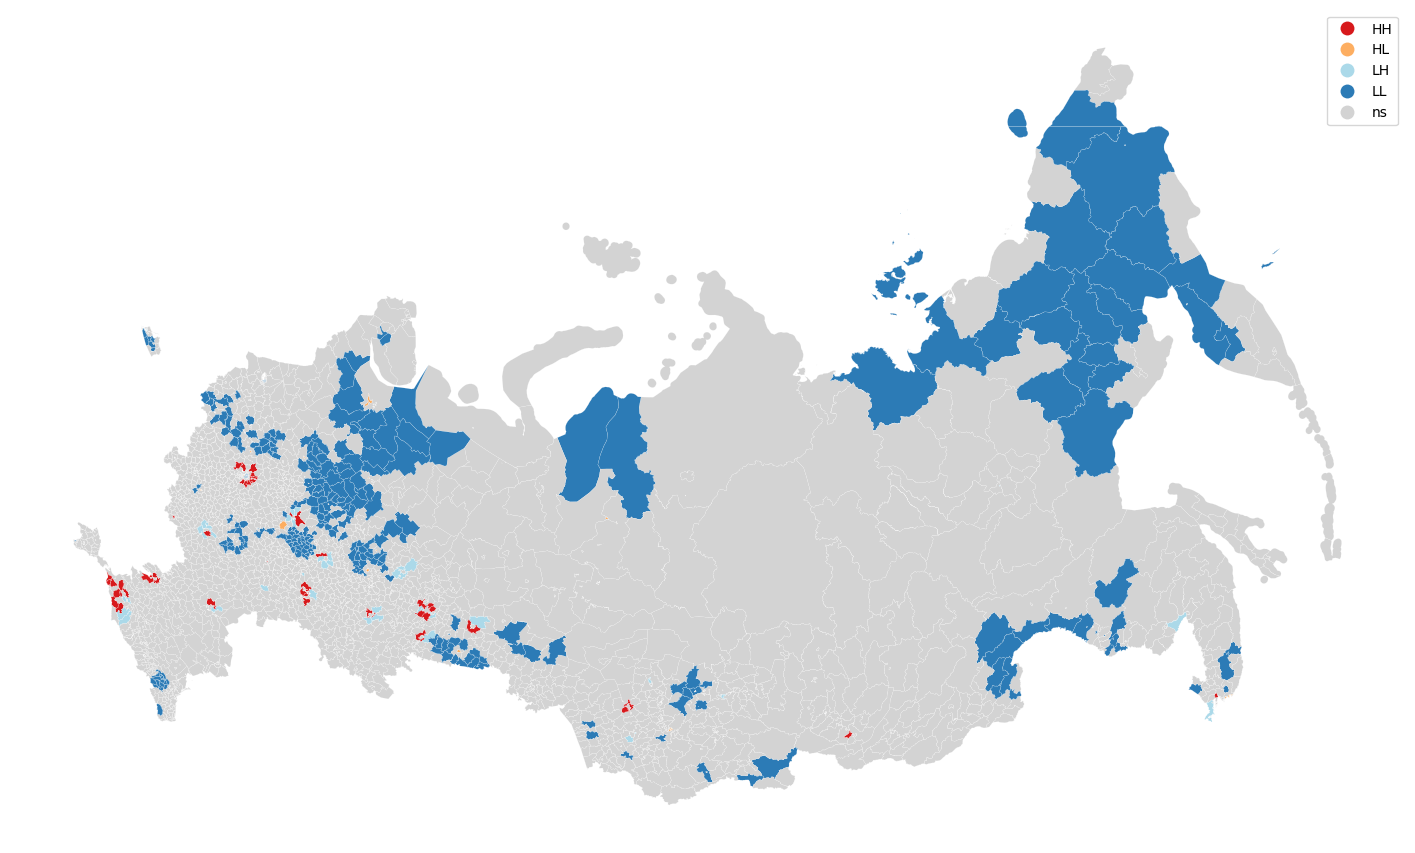

In [ ]:
# визуализируем lisa-кластеры и -outliers (локальный индекс Морана)

f, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 12))

splot.esda.lisa_cluster(moran_loc=lisa_reg, gdf=ms20_pmo_reg, p=0.05, ax=ax)

f.savefig('../output/sme/sme_2020.png', dpi='figure')


## рассчитываем разницу между показателем бд пмо и реестром мсп в 2020 году

In [21]:
# заполняем пропуски в indicator_value нулями (допущение)

ms20_pmo_reg['indicator_value'] = ms20_pmo_reg['indicator_value'].fillna(0)

# вычитаем количество точек мсп по реестру мсп из показателя бд пмо

ms20_pmo_reg['diff'] = ms20_pmo_reg['indicator_value'] - ms20_pmo_reg['sme_reg_frac']

# фильтруем строки, в которых показатель бд пмо и данные реестра мсп равны нулю

ms20_pmo_reg_diff = ms20_pmo_reg

ms20_pmo_reg_diff = ms20_pmo_reg_diff.loc[
    (ms20_pmo_reg_diff['indicator_value'] != 0) & (ms20_pmo_reg_diff['sme_reg'] != 0)
]


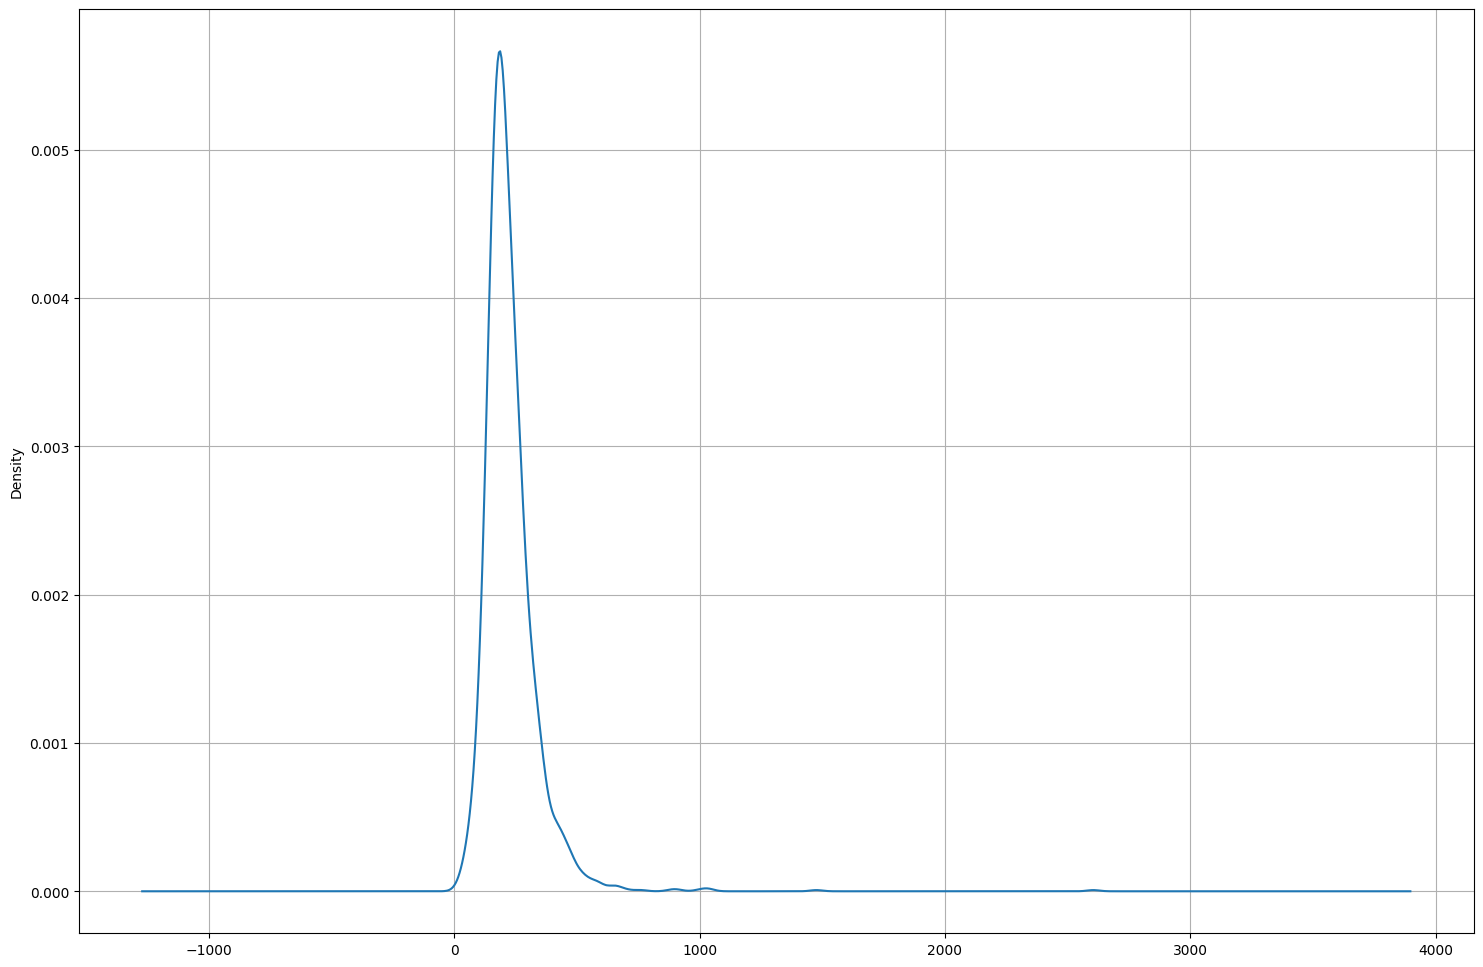

In [22]:
# визуализируем разницу между показателем бд пмо и реестром мсп

f, ax = plt.subplots(ncols=1, nrows=1, figsize=(18, 12))

ms20_pmo_reg_diff['diff'].plot(kind='kde')

ax.grid(True)

f.savefig('../output/sme/diff_2020.png', dpi='figure')
